In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd

from PIL import Image
from google.cloud import vision

# 1. Define a local folder for models
cache_dir = "./model_cache"
os.makedirs(cache_dir, exist_ok=True)

# 2. Tell Hugging Face to use this folder
os.environ['HF_HOME'] = cache_dir
os.environ['TRANSFORMERS_CACHE'] = cache_dir

# 3. It is recommended to make the following changes using terminal instead of code
# The reason behind this is, if the json key is used here in the code, 
# it is not safe, as the code might be shared between individual.
# export GOOGLE_APPLICATION_CREDENTIALS="/path/to/your/keys/service-account-key.json"

# Otherwise, use the following the inside this code:
# os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = r"/path/to/your/keys/service-account-key.json"

from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import BlipProcessor, BlipForConditionalGeneration

from tqdm.notebook import tqdm

In [3]:
!pip install git+https://github.com/openai/CLIP.git
import clip

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-k4lucc43
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-k4lucc43
  Resolved https://github.com/openai/CLIP.git to commit dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 31.0 MB/s eta 0:00:0000:010:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 52.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 

In [4]:
# --- CONFIGURATION ---
# UPDATE THESE PATHS TO YOUR LOCAL PATHS
TEXT_MODEL_NAME = "t5-base"  # Or your specific fine-tuned path
BLIP_MODEL_NAME = "Salesforce/blip-image-captioning-base"
CLIP_MODEL_NAME = "ViT-B/32"
CLIP_WEIGHTS_PATH = "/kaggle/input/best-models-musait/VSA/CLIP__best_model.pt" # Update this
TEXT_WEIGHTS_PATH = "/kaggle/input/best-models-musait/TSA/T5__best_model.pt" # Update this

MAX_LENGTH = 128
SENTIMENTS_TO_LABELS = {'negative':0,'neutral':1,'positive':2}
LABELS_TO_SENTIMENTS = {0: 'Negative', 1: 'Neutral', 2: "Positive"}

csv_filepath = "/kaggle/input/musait/MUSAIT__all_info_uniques.csv"
df = pd.read_csv(csv_filepath)
all_filenames = df["filename"]
all_ocr = df["OCR"]

In [5]:
# --- CLIP CLASSIFIER WRAPPER ---
class CLIPClassifier(nn.Module):
    def __init__(self, encoder, embed_dim, num_classes):
        super().__init__()
        self.encoder = encoder
        self.classifier = nn.Linear(embed_dim, num_classes)

    def forward(self, image):
        image = image.to(dtype=self.encoder.conv1.weight.dtype)
        with torch.no_grad():
            x = self.encoder(image)
        x = x.float()
        return self.classifier(x)

# --- MODEL LOADER ---
def load_core_models():
    """
    Loads all models onto the device once to be cached by Streamlit.
    """
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Loading models on {device}...")

    # 1. Load BLIP (Captioning)
    blip_processor = BlipProcessor.from_pretrained(BLIP_MODEL_NAME, cache_dir=cache_dir)
    blip_model = BlipForConditionalGeneration.from_pretrained(BLIP_MODEL_NAME, cache_dir=cache_dir).to(device)

    # 2. Load Text Model (DistilRoBERTa/T5)
    # Note: Ensure num_labels matches your training (e.g., 3 for Neg/Neu/Pos)
    text_tokenizer = AutoTokenizer.from_pretrained(TEXT_MODEL_NAME, cache_dir=cache_dir)
    text_model = AutoModelForSequenceClassification.from_pretrained(TEXT_MODEL_NAME, num_labels=3, cache_dir=cache_dir)
    
    # Load weights if they exist, otherwise use base (warning: base model won't predict sentiment correctly without fine-tuning)
    if os.path.exists(TEXT_WEIGHTS_PATH):
        text_model.load_state_dict(torch.load(TEXT_WEIGHTS_PATH, map_location=device))
    text_model.to(device)
    text_model.eval()

    # 3. Load CLIP (Visual)
    clip_path = os.path.join(cache_dir, "ViT-B-32.pt")
    clip_base, image_preprocess = clip.load(CLIP_MODEL_NAME, device=device, download_root=cache_dir)
    # We need the embed_dim from the visual part of CLIP (usually 512 for ViT-B/32)
    embed_dim = clip_base.visual.output_dim 
    
    image_model = CLIPClassifier(clip_base.visual, embed_dim=embed_dim, num_classes=3).to(device)
    if os.path.exists(CLIP_WEIGHTS_PATH):
        image_model.load_state_dict(torch.load(CLIP_WEIGHTS_PATH, map_location=device))
    image_model.eval()

    return {
        "device": device,
        "blip_processor": blip_processor,
        "blip_model": blip_model,
        "text_tokenizer": text_tokenizer,
        "text_model": text_model,
        "image_preprocess": image_preprocess,
        "image_model": image_model
    }

# --- HELPER: GOOGLE VISION OCR ---
def get_ocr_text(image_content):
    """
    Performs OCR using Google Vision API.
    """
    client = vision.ImageAnnotatorClient()
    image = vision.Image(content=image_content)
    response = client.text_detection(image=image)
    texts = response.text_annotations
    
    if texts:
        # texts[0] is the full text, subsequent indices are words
        return texts[0].description, texts[0] 
    return None, None
 
 
def check_text_detection_v1(image_path):
    with io.open(image_path, 'rb') as image_file:
        content = image_file.read()
    client = vision.ImageAnnotatorClient()
    
    image = vision.Image(content=content)
    text = None
    
    response = client.text_detection(image=image)
    texts = response.text_annotations
    return texts[0] if texts else False


def check_text_detection_v2(image_path):
    with io.open(image_path, 'rb') as image_file:
        content = image_file.read()
    client = vision.ImageAnnotatorClient()
    
    image = vision.Image(content=content)
    text = None
    
    response = client.text_detection(image=image)
    texts = response.text_annotations
    return texts if texts else False


# --- HELPER: ALPHA CALCULATION (Simplified v1) ---
def calculate_alpha(ocr_annotation, img_width, img_height):
    """
    Calculates the area of text relative to image area.
    """
    if not ocr_annotation:
        return 0.5 # Default if no text found via OCR

    img_area = img_width * img_height
    
    # Calculate bounding box of the full text
    vertices = ocr_annotation.bounding_poly.vertices
    x_values = [v.x for v in vertices]
    y_values = [v.y for v in vertices]
    
    txt_width = max(x_values) - min(x_values)
    txt_height = max(y_values) - min(y_values)
    
    txt_area = txt_width * txt_height
    alpha = txt_area / img_area
    
    # Clip alpha to reasonable bounds (e.g., don't let it be 0 or 1 purely based on size)
    return min(max(alpha, 0.2), 0.8)
    

def get_alpha_v1(texts, img_area):
    text = texts.description
    bounding_poly = texts.bounding_poly
    coordinates = []
    for vertex in bounding_poly.vertices:
        coordinates.append({"x": vertex.x, "y": vertex.y})
    
    x_values = [point['x'] for point in coordinates]
    y_values = [point['y'] for point in coordinates]
    txt_width = max(x_values) - min(x_values)
    txt_height = max(y_values) - min(y_values)

    txt_area = txt_width*txt_height
    txt_weightage = txt_area/img_area
    return txt_weightage
    

def get_alpha_v2(texts, img_area):
   total_text_area = 0
   for t in texts[1:]:
       vertices = [(v.x, v.y) for v in t.bounding_poly.vertices]
       text_area = polygon_area(vertices)
       total_text_area += text_area
       print(f"Word: {t.description}, Area: {text_area}")
   
   print("Total Area:", total_text_area)
   alpha = total_text_area/img_area
   return alpha

# --- MAIN INFERENCE PIPELINE (MeVITSA) ---
def mevitsa_analysis(image_filename, image_pil, image_bytes, models_dict, manual_alpha=None, gcv_api=1):
    """
    The MeVITSA Method:
    1. Extract Text (OCR from CSV) -> if failed, Generate Caption (BLIP).
    2. Get Text Sentiment (RoBERTa/T5).
    3. Get Image Sentiment (CLIP).
    4. Fuse using Alpha (Area-based or Manual).
    """
    device = models_dict["device"]
    
    # 1. VISUAL PIPELINE
    # ------------------
    image_tensor = models_dict["image_preprocess"](image_pil).unsqueeze(0).to(device)
    with torch.no_grad():
        visual_logits = models_dict["image_model"](image_tensor)
        visual_probs = F.softmax(visual_logits, dim=1).cpu().numpy().flatten()
    
    # 2. TEXT PIPELINE
    # ----------------
    ocr_text = ""
    final_text = ""
    source = "BLIP" # Default source
    
    if gcv_api==1:
        ocr_text, ocr_annotation = get_ocr_text(image_bytes)
        source = "OCR"
        final_text = ocr_text
    else:
		# Check if image exists in the CSV data
		# Note: using .values ensures we check the content, not the index
        if image_filename in all_filenames.values:
            matched_row = df.loc[df["filename"] == image_filename].iloc[0]
            ocr_text = matched_row["OCR"]
            # Logic: If OCR exists and is not empty/NaN, use it. Otherwise, use BLIP.
            if pd.notna(ocr_text) and str(ocr_text).strip() != "":
                final_text = str(ocr_text)
                source = "OCR"
            else:
                # Fault Tolerance: Generate Caption via BLIP
                source = "BLIP"
                inputs = models_dict["blip_processor"](images=image_pil, return_tensors="pt").to(device)
                out = models_dict["blip_model"].generate(**inputs)
                # print(out)
                # print(out[0])
                final_text = models_dict["blip_processor"].decode(out[0], skip_special_tokens=True)
    
    # Tokenize and Predict
    inputs = models_dict["text_tokenizer"](
        final_text, 
        return_tensors="pt", 
        truncation=True, 
        padding=True, 
        max_length=MAX_LENGTH
    ).to(device)
    
    with torch.no_grad():
        text_outputs = models_dict["text_model"](**inputs)
        text_probs = F.softmax(text_outputs.logits, dim=1).cpu().numpy().flatten()

    # 3. FUSION (MeVITSA LOGIC)
    # ----------------------
    if manual_alpha is not None:
        alpha = manual_alpha
    else:
        # Note: Since we are reading from CSV, we might not have 'ocr_annotation' 
        # for area calculation unless it's also saved in the CSV. 
        # For now, we default to 0.5 if using BLIP or if area data is missing.
        alpha = 0.5 

    # Weighted Average
    final_probs = (alpha * text_probs) + ((1 - alpha) * visual_probs)
    pred_idx = np.argmax(final_probs)
    
    return {
        "final_class": LABELS_TO_SENTIMENTS[pred_idx],
        "final_probs": final_probs,
        "text_probs": text_probs,
        "visual_probs": visual_probs,
        "text_content": final_text,
        "text_source": source,
        "alpha_used": alpha
    }

# DocImSentv1 inference

In [6]:
# ---------------- CONFIGURATION ----------------
# Path to your image folder
DATASET_FOLDER = "/kaggle/input/musait/basket_unique" 

# Ensure models are loaded
# if 'models' not in locals():
print("Loading models...")
models = load_core_models()

Loading models...
Loading models on cpu...


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Some weights of T5ForSequenceClassification were not initialized from the model checkpoint at t5-base and are newly initialized: ['classification_head.dense.bias', 'classification_head.dense.weight', 'classification_head.out_proj.bias', 'classification_head.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [7]:
# ---------------- HELPER: PARSE LABEL ----------------
def get_true_label(filename):
    """
    Parses sentiment from filename.
    Assumes format like: 'positive_123.jpg' or '123_negative.jpg'
    """
    filename_lower = filename.lower()
    if "positive" in filename_lower:
        return "Positive"
    elif "negative" in filename_lower:
        return "Negative"
    elif "neutral" in filename_lower:
        return "Neutral"
    return None

In [23]:
# ---------------- MAIN ANALYSIS LOOP ----------------
results = []
valid_extensions = ('.jpg', '.jpeg', '.png', ".JPG")
image_files = [f for f in os.listdir(DATASET_FOLDER) if f.lower().endswith(valid_extensions)]

print(f"Found {len(image_files)} images. Starting analysis...")

Found 2054 images. Starting analysis...


In [24]:
for img_name in tqdm(image_files):
    img_path = os.path.join(DATASET_FOLDER, img_name)
    
    # 1. Get Ground Truth
    true_label = get_true_label(img_name)
    if not true_label:
        continue # Skip if no label found in filename
        
    # 2. Prepare Image
    try:
        image_pil = Image.open(img_path).convert("RGB")
        # specific to your pipeline: needs bytes for OCR check (if using API)
        # or filename lookup if relying on CSV
        with open(img_path, "rb") as f:
            image_bytes = f.read()
            
        # 3. Run MeViTSA Inference
        # Note: We pass img_name because your model looks it up in the CSV for OCR
        prediction = mevitsa_analysis(
            image_filename=img_name, 
            image_pil=image_pil, 
            image_bytes=image_bytes, 
            models_dict=models,
            gcv_api=0
        )
        # if prediction['text_source']=="BLIP":
        #     print(prediction['text_content'])
        # 4. Log Data
        results.append({
            "filename": img_name,
            "true_label": true_label,
            "pred_label": prediction['final_class'],
            "confidence": max(prediction['final_probs']),
            "text_source": prediction['text_source'],
            "alpha": prediction['alpha_used'],
            "extracted_text": prediction['text_content'] # [:50] + "..." # Truncate for display
        })
        
    except Exception as e:
        print(f"Error processing {img_name}: {e}")
    # print(results)
    # break

  0%|          | 0/2054 [00:00<?, ?it/s]


✅ Overall Accuracy: 95.9591%

📊 Classification Report:
              precision    recall  f1-score   support

    Negative     0.9748    0.9567    0.9656       646
     Neutral     0.9198    0.9787    0.9483       656
    Positive     0.9848    0.9455    0.9647       752

    accuracy                         0.9596      2054
   macro avg     0.9598    0.9603    0.9595      2054
weighted avg     0.9609    0.9596    0.9598      2054



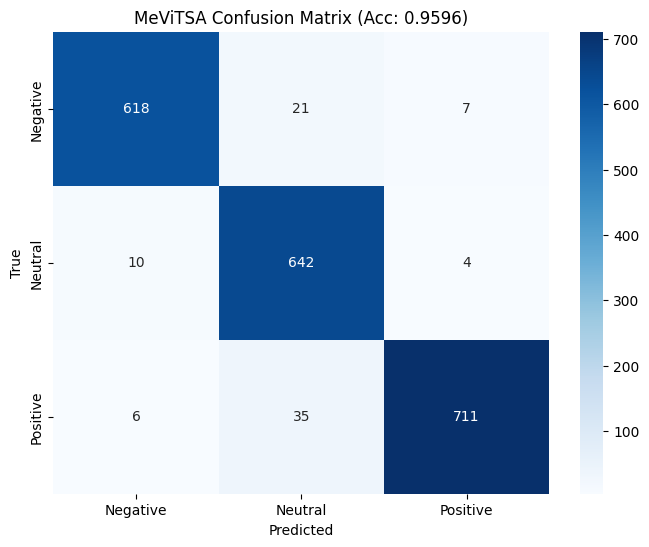

In [25]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------- METRICS & VISUALIZATION ----------------
df_results = pd.DataFrame(results)

# 1. Basic Accuracy
acc = accuracy_score(df_results['true_label'], df_results['pred_label'])
print(f"\n✅ Overall Accuracy: {acc:.4%}")

# 2. Classification Report
print("\n📊 Classification Report:")
print(classification_report(df_results['true_label'], df_results['pred_label'], digits=4))

# 3. Confusion Matrix
plt.figure(figsize=(8, 6))
labels = ["Negative", "Neutral", "Positive"]
cm = confusion_matrix(df_results['true_label'], df_results['pred_label'], labels=labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title(f"MeViTSA Confusion Matrix (Acc: {acc:.4f})")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


✅ Overall Accuracy: 95.9591%

📊 Classification Report:
              precision    recall  f1-score   support

    Negative     0.9748    0.9567    0.9656       646
     Neutral     0.9198    0.9787    0.9483       656
    Positive     0.9848    0.9455    0.9647       752

    accuracy                         0.9596      2054
   macro avg     0.9598    0.9603    0.9595      2054
weighted avg     0.9609    0.9596    0.9598      2054



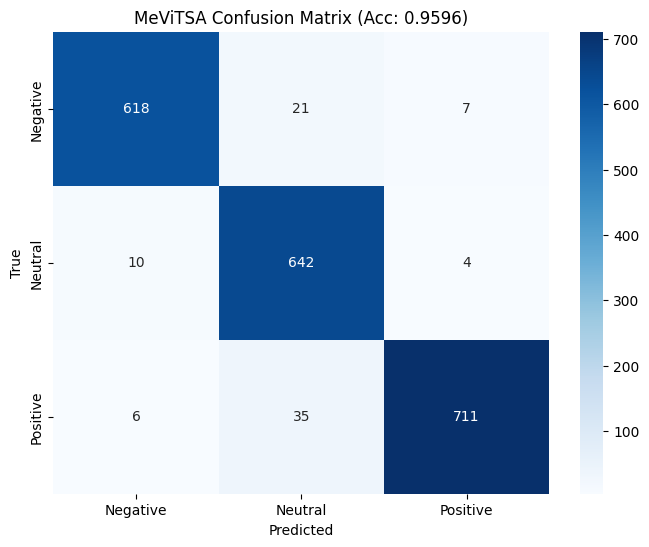

In [26]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------- METRICS & VISUALIZATION ----------------
df_results = pd.DataFrame(results)

# 1. Basic Accuracy
acc = accuracy_score(df_results['true_label'], df_results['pred_label'])
print(f"\n✅ Overall Accuracy: {acc:.4%}")

# 2. Classification Report
print("\n📊 Classification Report:")
print(classification_report(df_results['true_label'], df_results['pred_label'], digits=4))

# 3. Confusion Matrix
plt.figure(figsize=(8, 6))
labels = ["Negative", "Neutral", "Positive"]
cm = confusion_matrix(df_results['true_label'], df_results['pred_label'], labels=labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title(f"MeViTSA Confusion Matrix (Acc: {acc:.4f})")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [27]:
# 4. Failure Analysis (High Confidence Errors)
print("\n⚠️ Top 5 High-Confidence Errors (Worst Failures):")
errors = df_results[df_results['true_label'] != df_results['pred_label']]
top_errors = errors.sort_values(by="confidence", ascending=False).head(5)

display(top_errors[['filename', 'true_label', 'pred_label', 'confidence', 'text_source', 'extracted_text']])


⚠️ Top 5 High-Confidence Errors (Worst Failures):


,filename,true_label,pred_label,confidence,text_source,extracted_text
1315,positive_501.jpg,Positive,Neutral,0.966988,OCR,slate\n@PleaseBeGneiss\nthe geometry is too co...
704,negative_648.jpg,Negative,Positive,0.935829,OCR,You don't always have to pretend to be strong....
1327,negative_658.jpg,Negative,Positive,0.935743,OCR,"UniGreet.com\nTrust me,\nI will never come int..."
641,neutral_224.jpg,Neutral,Positive,0.914616,OCR,MILLENIAL MINDSET\nIF YOU GENUINELY WANT\nSOME...
1712,negative_575.jpg,Negative,Neutral,0.905706,OCR,when you accidentally open a\nmessage and now ...


In [28]:
errors['extracted_text'].iloc[1]

'a large black stone'

In [29]:
df_results['text_source'].unique()

array(['OCR', 'BLIP'], dtype=object)

In [30]:
# 4. Failure Analysis (High Confidence Errors)
print("\n⚠️ Top 20 High-Confidence Errors (Worst Failures):")
errors = df_results[df_results['true_label'] != df_results['pred_label']]
top_errors = errors.sort_values(by="confidence", ascending=False).head(20)

display(top_errors[['filename', 'true_label', 'pred_label', 'confidence', 'text_source', 'extracted_text']])


⚠️ Top 20 High-Confidence Errors (Worst Failures):


,filename,true_label,pred_label,confidence,text_source,extracted_text
1315,positive_501.jpg,Positive,Neutral,0.966988,OCR,slate\n@PleaseBeGneiss\nthe geometry is too co...
704,negative_648.jpg,Negative,Positive,0.935829,OCR,You don't always have to pretend to be strong....
1327,negative_658.jpg,Negative,Positive,0.935743,OCR,"UniGreet.com\nTrust me,\nI will never come int..."
641,neutral_224.jpg,Neutral,Positive,0.914616,OCR,MILLENIAL MINDSET\nIF YOU GENUINELY WANT\nSOME...
1712,negative_575.jpg,Negative,Neutral,0.905706,OCR,when you accidentally open a\nmessage and now ...
38,positive_649.jpg,Positive,Negative,0.897771,OCR,"""All the News\nWe Hope to Print\nVOL CLVI..No...."
1210,negative_688.jpg,Negative,Positive,0.866907,OCR,"""The key to\nemotional\nenlightenment is the\n..."
1481,negative_556.jpeg,Negative,Neutral,0.866378,OCR,when you're cleaning your room and\nfind that ...
1761,negative_124.jpeg,Negative,Neutral,0.865089,OCR,амс\nEL CAMINO\nWhat the hell is this?\nWhat?\...
1912,positive_061.jpg,Positive,Negative,0.850658,BLIP,a man in a red jacket and helmet is walking th...


In [31]:
df_results['extracted_text'][1040]

'a woman holding a cat in her arms'

In [32]:
df_results[df_results['text_source']=='BLIP']

,filename,true_label,pred_label,confidence,text_source,alpha,extracted_text
31,neutral_105.jpeg,Neutral,Neutral,0.554547,BLIP,0.5,a man sitting on a rock in front of a waterfall
43,negative_044.jpg,Negative,Negative,0.959897,BLIP,0.5,a woman and child walk through a rubble - stre...
67,negative_140.jpg,Negative,Neutral,0.448314,BLIP,0.5,a large black stone
94,negative_024.jpg,Negative,Negative,0.772248,BLIP,0.5,people are gathered around a muddy puddle
131,negative_106.jpg,Negative,Neutral,0.643456,BLIP,0.5,a young boy with his mouth open
...,...,...,...,...,...,...,...
2001,positive_062.jpg,Positive,Positive,0.427442,BLIP,0.5,a sunset over the ocean with clouds and trees
2007,negative_094.jpg,Negative,Neutral,0.477746,BLIP,0.5,a boy sitting on a ledge
2016,neutral_028.jpg,Neutral,Neutral,0.680855,BLIP,0.5,a white car parked in a garage
2048,negative_054.jpg,Negative,Negative,0.874078,BLIP,0.5,soldiers in the trenches


In [34]:
errors.to_csv('error_analysis.csv')